In [ ]:
!pip install pytorch-fid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
random_seed = 42
torch.manual_seed(random_seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Data Loading

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.66MB/s]


<h1>Model</h1>
Define the model architecture and diffusion process components. We use a simple U-Net–like convolutional network to predict noise, and a diffusion class to handle the noise schedule and algorithms.

In [ ]:
class DenoiseNet(nn.Module):
    def __init__(self, input_channels=2, base_channels=64):
        super(DenoiseNet, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, base_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels*2, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(base_channels*2, base_channels*4, kernel_size=4, stride=2, padding=1)
        self.deconv1 = nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1)
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=3, padding=1)
    def forward(self, x):
        d1 = torch.relu(self.conv1(x))
        d2 = torch.relu(self.conv2(d1))
        d3 = torch.relu(self.conv3(d2))
        u1 = torch.relu(self.deconv1(d3))
        u1 = u1 + d2
        u2 = torch.relu(self.deconv2(u1))
        u2 = u2 + d1
        return self.conv_out(u2)
class DiffuseNet:
    def __init__(self, model, num_steps=1000, beta_start=1e-4, beta_end=0.02):
        self.model = model.to(device)
        self.num_steps = num_steps
        self.beta_schedule = torch.linspace(beta_start, beta_end, num_steps).to(device)
        self.alpha = 1.0 - self.beta_schedule

        self.alpha_prod = torch.cumprod(self.alpha, dim=0)
        self.sqrt_alpha_prod = torch.sqrt(self.alpha_prod)
        self.sqrt_one_minus_alpha_prod = torch.sqrt(1 - self.alpha_prod)

    def compute_loss(self, x0):
        """Loss calc"""
        batch_size = x0.size(0)
        t = torch.randint(0, self.num_steps, (batch_size,), device=device)

        noise = torch.randn_like(x0)
        alpha_prod_t = self.alpha_prod[t].view(-1, 1, 1, 1)
        sqrt_alpha_prod_t = self.sqrt_alpha_prod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_prod_t = self.sqrt_one_minus_alpha_prod[t].view(-1, 1, 1, 1)
        x_t = sqrt_alpha_prod_t * x0 + sqrt_one_minus_alpha_prod_t * noise
        t_norm = t.float() / self.num_steps
        t_channel = t_norm.view(-1, 1, 1, 1).repeat(1, 1, x0.shape[2], x0.shape[3])

        pred_noise = self.model(torch.cat([x_t, t_channel], dim=1))
        return torch.mean((noise - pred_noise) ** 2)

    def generate_images(self, num_samples):
        """Generate imgs whil removing noise."""
        self.model.eval()
        x = torch.randn(num_samples, 1, 28, 28, device=device)
        for t in reversed(range(self.num_steps)):
            t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
            t_channel = (t_tensor.float() / self.num_steps).view(-1, 1, 1, 1).repeat(1, 1, x.shape[2], x.shape[3])
            pred_noise = self.model(torch.cat([x, t_channel], dim=1))

            beta_t = self.beta_schedule[t]
            alpha_t = 1.0 - beta_t
            alpha_prod_t = self.alpha_prod[t]
            x_prev_mean = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_prod_t).sqrt() * pred_noise)
            if t > 0:
                z = torch.randn_like(x)
                x = x_prev_mean + beta_t.sqrt() * z
            else:

                x = x_prev_mean
        return x


<h1>Training

In [ ]:
denoise_model = DenoiseNet()
diffusion = DiffuseNet(model=denoise_model, num_steps=1000)
optimizer = optim.Adam(diffusion.model.parameters(), lr=1e-3)
epochs = 15
for epoch in range(1, epochs+1):
    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device)
        optimizer.zero_grad()
        loss = diffusion.compute_loss(real_imgs)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}/{epochs} - Loss: {loss.item():.4f}")


Epoch 1/15 - Loss: 0.0450
Epoch 2/15 - Loss: 0.0457
Epoch 3/15 - Loss: 0.0344
Epoch 4/15 - Loss: 0.0333
Epoch 5/15 - Loss: 0.0279
Epoch 6/15 - Loss: 0.0331
Epoch 7/15 - Loss: 0.0282
Epoch 8/15 - Loss: 0.0294
Epoch 9/15 - Loss: 0.0242
Epoch 10/15 - Loss: 0.0261
Epoch 11/15 - Loss: 0.0205
Epoch 12/15 - Loss: 0.0307
Epoch 13/15 - Loss: 0.0425
Epoch 14/15 - Loss: 0.0206
Epoch 15/15 - Loss: 0.0226


Let's plot it to be better see how did the process go!

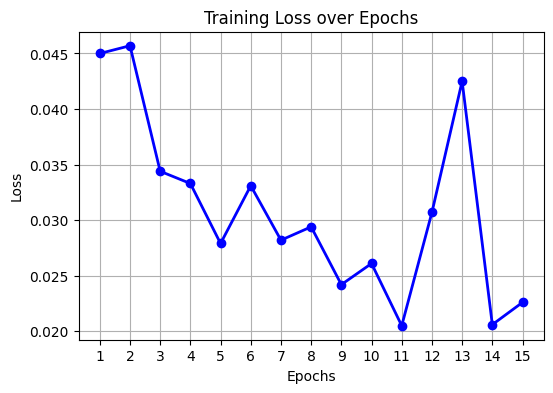

In [ ]:
import matplotlib.pyplot as plt
loss_data = [0.0450, 0.0457, 0.0344, 0.0333, 0.0279, 0.0331, 0.0282, 0.0294, 0.0242, 0.0261, 0.0205, 0.0307, 0.0425, 0.0206, 0.0226]
epochs = list(range(1, 16))
plt.figure(figsize=(6, 4))
plt.plot(epochs, loss_data, marker='o', color='b', linewidth=2)
plt.title("Training Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)

plt.grid(True)
plt.show()

<h1>Sampling

In [ ]:
num_samples = 16
generated_images = diffusion.generate_images(num_samples)
generated_images = (generated_images * 0.5 + 0.5).clamp(0, 1)

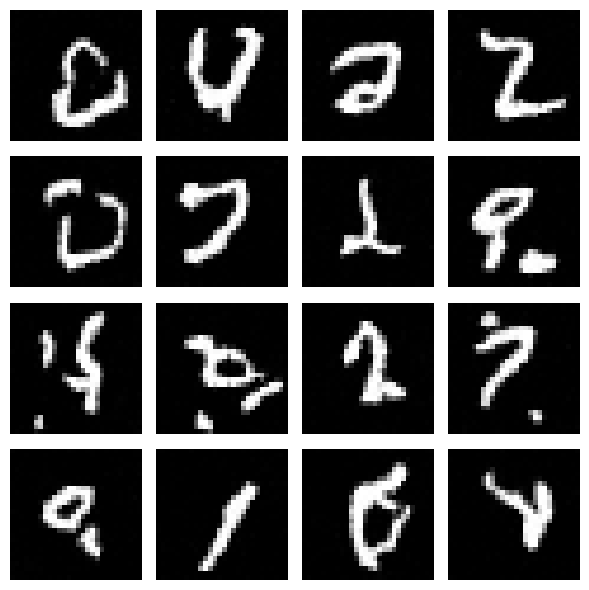

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.axis('off')
    ax.imshow(generated_images[i, 0].cpu().detach().numpy(), cmap='gray')
plt.tight_layout()
plt.show()


This cell computes evaluation metrics for the generated images:
<ol>
<li>Preprocessing:</li>

Denormalizes generated and real MNIST images from [-1, 1] to [0, 1].

<li>Compute MSE & PSNR:

Calculates Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR) between real and generated images.

<li>Save Images for FID:

Saves real and generated images to disk for FID calculation.

<li>Compute FID:

Calculates Fréchet Inception Distance (FID) between the real and generated images.
</ol>

These metrics evaluate the quality and similarity of the generated images to the real MNIST dataset.










MSE: 0.2815, PSNR: 5.51 dB


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 210MB/s]
100%|██████████| 2/2 [00:07<00:00,  3.68s/it]


FID score: 136.79
